In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Decision Trees vs Logistic Regression: Predicting Breast Cancer

### Context & Goal

You are a data scientist working at a healthcare analytics startup. Your task is to build a model that can help doctors identify whether a tumour is **benign or malignant** based on cell nucleus measurements.
You will compare two classification approaches — a **Decision Tree** and **Logistic Regression** — to determine which performs better and how their decision boundaries differ.


### Learning Targets

* Load and explore a real-world medical dataset from scratch.
* Train and evaluate a **Decision Tree Classifier** for binary classification.
* Train and compare a **Logistic Regression** model on the same data.
* Visualise and interpret differences in decision boundaries and accuracy.


### Dataset

**Name:** Wisconsin Breast Cancer Dataset<br>
**Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29)<br>
**Description:**
Contains 569 observations of breast tumour cells with 30 numerical features describing their characteristics (e.g., radius, texture, smoothness).<br>
**Target variable:** `diagnosis` (`M` = malignant, `B` = benign)<br>
**Why this dataset:** It’s a canonical example for binary classification tasks and interpretable medical applications.<br>

### Task Instructions

1. **Data Loading and Cleaning**

   * Import the dataset using `pandas` or `sklearn.datasets.load_breast_cancer()`.
   * Convert it to a `DataFrame` with descriptive column names.
   * Encode the target variable into binary form (e.g., 1 = malignant, 0 = benign).
   * Perform a basic exploratory analysis (shape, missing values, feature summary).


In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

In [3]:
# metadata
meta = breast_cancer_wisconsin_diagnostic.metadata

# Create a cleaned metadata DataFrame with proper structure
meta_df = pd.DataFrame(
	[(k, v) for k, v in meta.items() if v is not None], columns=["Attribute", "Value"]
)
display(meta_df)


,Attribute,Value
0,uci_id,17
1,name,Breast Cancer Wisconsin (Diagnostic)
2,repository_url,https://archive.ics.uci.edu/dataset/17/breast+...
3,data_url,https://archive.ics.uci.edu/static/public/17/d...
4,abstract,Diagnostic Wisconsin Breast Cancer Database.
5,area,Health and Medicine
6,tasks,[Classification]
7,characteristics,[Multivariate]
8,num_instances,569
9,num_features,30


In [4]:
y = y["Diagnosis"].map({"M": 1, "B": 0})

In [5]:
X.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


2. **Feature Selection and Splitting**

   * For a simple visual comparison, use only two features:

     * `mean radius` (`radius_mean`)
     * `mean number of concave points` (`concave points_mean`)
   * Split the dataset into **training (80%)** and **testing (20%)** subsets using `train_test_split`.

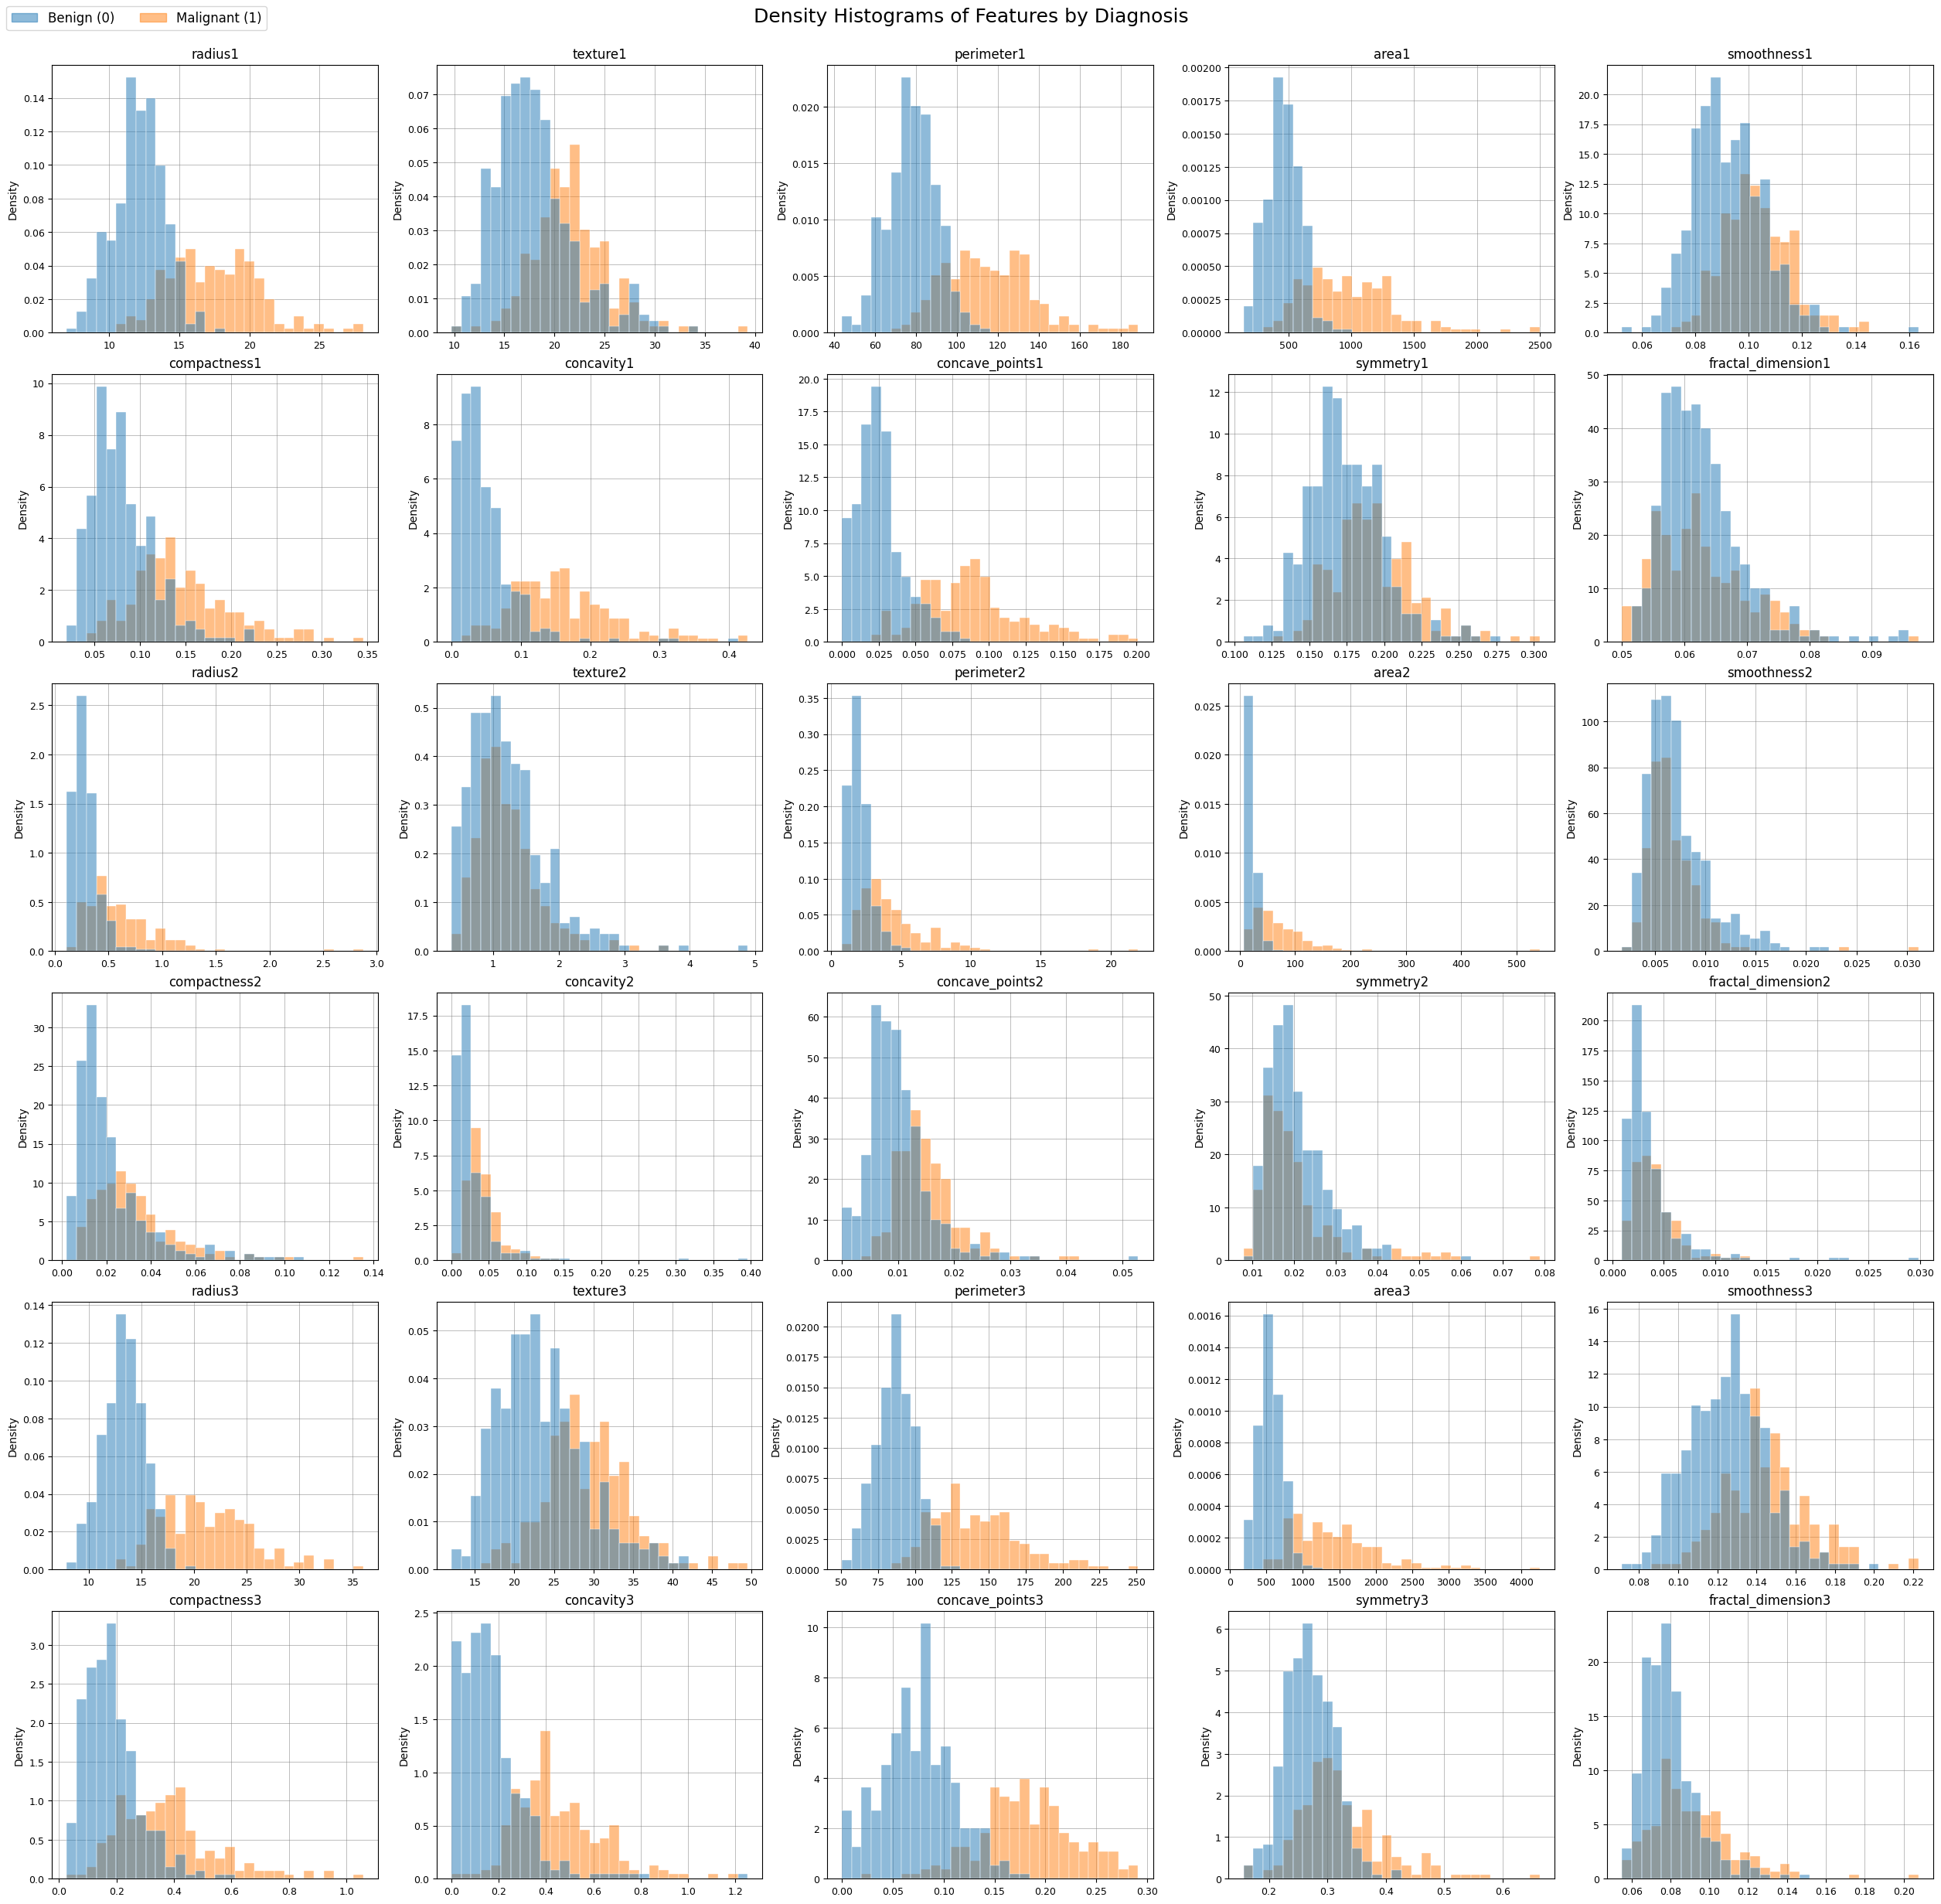

In [22]:
# Combine features with target for plotting
df_plot = X.copy()
df_plot["diagnosis"] = y

feature_names = X.columns
num_features = len(feature_names)

fig, axes = plt.subplots(6, 5, figsize=(25, 24), constrained_layout=True)
axes = axes.ravel()

for axis, feature in zip(axes, feature_names):
	sns.histplot(
		data=df_plot,
		x=feature,
		hue="diagnosis",
		hue_order=[0, 1],
		stat="density",
		bins=30,  # Maintained for smoother histograms
		alpha=0.5,
		edgecolor="white",
		linewidth=0.3,
		ax=axis,
		legend=False,  # Disable per-plot legends
	)
	axis.set_title(feature, fontsize=12)
	axis.set_xlabel("")
	axis.set_ylabel("Density", fontsize=10)
	axis.tick_params(axis="both", labelsize=9)
	axis.grid(True, alpha=0.6, linewidth=0.6, color="grey")
	axis.set_axisbelow(True)

# Single, consistent legend positioned outside the plots
handles = [
	plt.Rectangle((0, 0), 1, 1, color=sns.color_palette()[0], alpha=0.5),
	plt.Rectangle((0, 0), 1, 1, color=sns.color_palette()[1], alpha=0.5),
]
fig.legend(
	handles,
	["Benign (0)", "Malignant (1)"],
	loc="upper left",
	ncol=2,
	frameon=True,
	fontsize=12,
)

# Overall figure adjustments for readability
fig.suptitle("Density Histograms of Features by Diagnosis", fontsize=18, y=1.02)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X_simple = X[["radius1", "concavity1"]].copy()

X_train, X_test, y_train, y_test = train_test_split(
	X_simple, y, test_size=0.2, stratify=y, random_state=42
)

3. **Model 1: Decision Tree Classifier**

   * Import and instantiate `DecisionTreeClassifier` from `sklearn.tree` with:

     * `max_depth = 6`
     * `random_state = 1`
   * Fit the model to the training data.
   * Predict on the test set and store predictions in `y_pred_tree`.

In [8]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(max_depth=6, random_state=42)

dtc.fit(X_train, y_train)

y_pred_tree = dtc.predict(X_test)

4. **Model Evaluation**

   * Import `accuracy_score` from `sklearn.metrics`.
   * Compute and print the accuracy of the Decision Tree model.
   * Optionally, print a confusion matrix and classification report for deeper insight.

In [10]:
from sklearn.metrics import accuracy_score, classification_report

In [14]:
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_tree)
print(f"Decision Tree Accuracy: {accuracy:.4f}")

Decision Tree Accuracy: 0.9035


In [12]:
print(classification_report(y_true=y_test, y_pred=y_pred_tree))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93        72
           1       0.92      0.81      0.86        42

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.90      0.90      0.90       114



5. **Model 2: Logistic Regression**

   * Import and train a `LogisticRegression` model (with `random_state=1`).
   * Fit it on the same training data.
   * Predict on the test set (`y_pred_logreg`) and compute accuracy.


In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)
y_pred_logreg = dtc.predict(X_test)


In [16]:
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_logreg)
print(f"Decision Tree Accuracy: {accuracy:.4f}")

Decision Tree Accuracy: 0.9035


In [17]:
print(classification_report(y_true=y_test, y_pred=y_pred_logreg))


              precision    recall  f1-score   support

           0       0.90      0.96      0.93        72
           1       0.92      0.81      0.86        42

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.90      0.90      0.90       114



6. **Comparison and Visualisation**

   * Plot the decision boundaries of both models using a custom plotting function or matplotlib (you may adapt from examples online).
   * Compare their accuracy and explain the difference in decision regions (linear vs rectangular).


Decision Tree feature names: ['radius1' 'concavity1']
Logistic Regression feature names: ['radius1' 'concavity1']


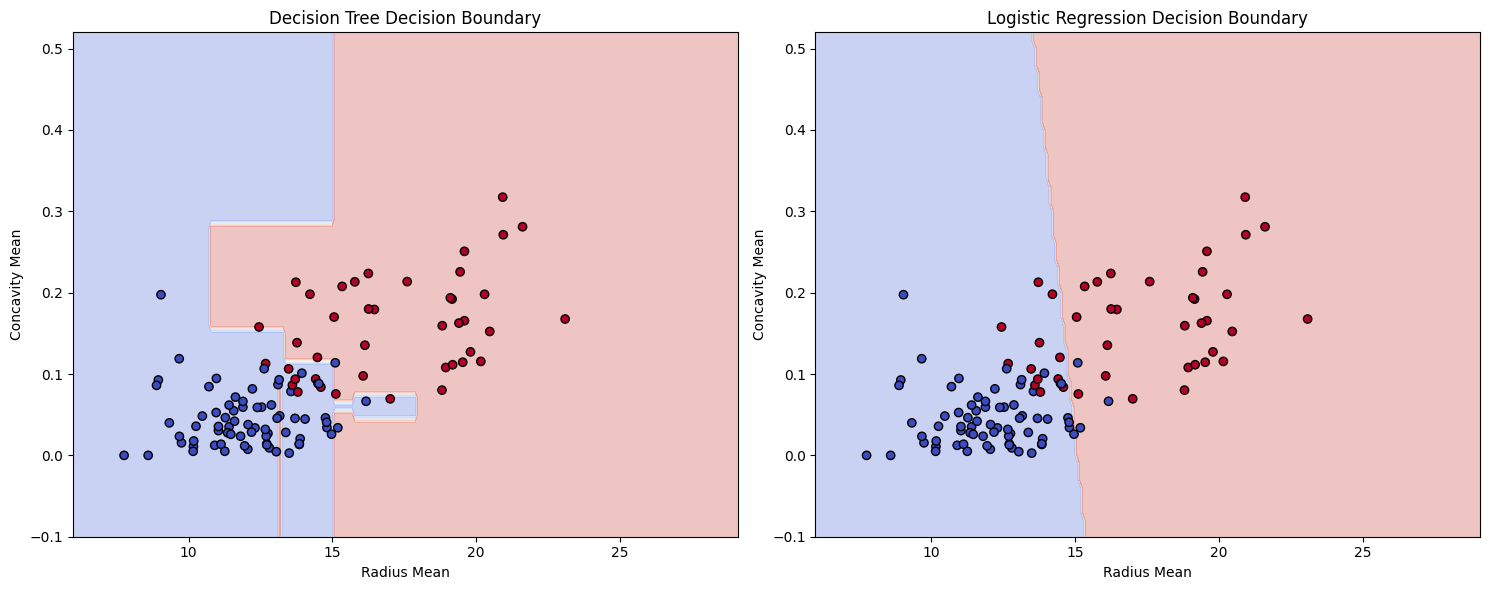

In [19]:
# Assuming dtc, logreg, X_simple, X_test, y_test, y_pred_tree are defined earlier.
# After fitting dtc and logreg, add these prints to verify feature names:
print("Decision Tree feature names:", dtc.feature_names_in_)
print("Logistic Regression feature names:", logreg.feature_names_in_)

# Use the verified feature names below (replace if needed based on the print output)
feature_col1 = "radius1"
feature_col2 = "concavity1"

# Create mesh grid for decision boundary plotting
x_min, x_max = X_simple[feature_col1].min() - 1, X_simple[feature_col1].max() + 1
y_min, y_max = X_simple[feature_col2].min() - 0.1, X_simple[feature_col2].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.01))

# Create DataFrame with proper column names for predictions
mesh_df = pd.DataFrame({feature_col1: xx.ravel(), feature_col2: yy.ravel()})


mesh_df = pd.DataFrame({feature_col1: xx.ravel(), feature_col2: yy.ravel()})


# Predict on mesh grid
Z_tree = dtc.predict(mesh_df).reshape(xx.shape)
Z_logreg = logreg.predict(mesh_df).reshape(xx.shape)

# Create subplots for side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Decision Tree decision boundary
ax1.contourf(xx, yy, Z_tree, alpha=0.3, cmap="coolwarm")
ax1.scatter(
	X_test[feature_col1],
	X_test[feature_col2],
	c=y_test,
	cmap="coolwarm",
	edgecolors="black",
)
ax1.set_title("Decision Tree Decision Boundary")
ax1.set_xlabel("Radius Mean")
ax1.set_ylabel("Concavity Mean")

# Plot Logistic Regression decision boundary
ax2.contourf(xx, yy, Z_logreg, alpha=0.3, cmap="coolwarm")
ax2.scatter(
	X_test[feature_col1],
	X_test[feature_col2],
	c=y_test,
	cmap="coolwarm",
	edgecolors="black",
)
ax2.set_title("Logistic Regression Decision Boundary")
ax2.set_xlabel("Radius Mean")
ax2.set_ylabel("Concavity Mean")

plt.tight_layout()
plt.show()

### Evaluation

You’ve successfully completed the exercise when:

* Both models train and evaluate correctly without errors.
* Accuracy scores are printed and compared.
* You provide an interpretation (in markdown or notebook text) of which model performed better and **why** based on their nature and boundaries.
